1. Carga de datos:

In [2]:
import pandas as pd
import importlib.util
import os

ruta_py = os.path.join('..', 'src', 'retail-sales-analysis_P5_Final.py')

spec = importlib.util.spec_from_file_location("modulo_p5", ruta_py)
modulo_p5 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(modulo_p5)

datos = pd.read_csv('../data/retail_sales_final_P4.csv') 

print("Éxito: ¡Módulo importado y datos cargados correctamente desde las carpetas raíz!")

Éxito: ¡Módulo importado y datos cargados correctamente desde las carpetas raíz!


In [3]:
datos.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Ingreso Total,Ventas Normalizadas,Categoria Venta,Mes,Rango_Etario,Desviacion_Media,Puntos_Lealtad
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.06,Media,11,Adulto,-317.475570,0.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.49,Media,2,Adulto,556.752137,100.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.00,Baja,1,Senior,-428.786550,0.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.24,Media,5,Adulto,56.752137,25.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.04,Baja,5,Adulto,-367.475570,0.0


** Exporar si existen duplicados

In [4]:
print("--- BUSCANDO REGISTROS REPETIDOS ---")

filas_vistas = []
duplicados_encontrados = []

for fila in datos:
    # Convertir la fila a una lista
    fila_lista = list(fila)
    
    if fila_lista in filas_vistas:
        duplicados_encontrados.append(fila_lista)
    else:
        filas_vistas.append(fila_lista)

print(f"Cantidad de filas duplicadas: {len(duplicados_encontrados)}")

if len(duplicados_encontrados) > 0:
    print("Se encontraron datos repetidos. Es necesario eliminarlos para no alterar las estadísticas.")

--- BUSCANDO REGISTROS REPETIDOS ---
Cantidad de filas duplicadas: 0


3. Análisis Descriptivo y Visualización

3.1 Estadísticas Descriptivas

In [5]:
# Estadísticas para variables numéricas (Edad, Cantidad, Total Amount, Puntos_Lealtad)
stats_numericas = datos.describe()

# Variables categóricas
stats_categoricas = datos.describe(include=['object', 'string'])

print("--- ESTADÍSTICAS VARIABLES NUMÉRICAS ---")
display(stats_numericas.round(2))

print("\n--- ESTADÍSTICAS VARIABLES CATEGÓRICAS ---")
display(stats_categoricas)

--- ESTADÍSTICAS VARIABLES NUMÉRICAS ---


,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Ingreso Total,Ventas Normalizadas,Mes,Desviacion_Media,Puntos_Lealtad
count,1000.00,1000.00,1000.00,1000.00,1000.0,1000.0,1000.00,1000.00,1000.00,1000.00
mean,500.50,41.39,2.51,179.89,456.0,456.0,0.22,6.55,0.00,49.78
std,288.82,13.68,1.13,189.68,560.0,560.0,0.28,3.45,559.91,85.39
min,1.00,18.00,1.00,25.00,25.0,25.0,0.00,1.00,-442.48,0.00
25%,250.75,29.00,1.00,30.00,60.0,60.0,0.02,4.00,-392.48,0.00
50%,500.50,42.00,3.00,50.00,135.0,135.0,0.06,6.00,-320.36,0.00
75%,750.25,53.00,4.00,300.00,900.0,900.0,0.44,10.00,432.52,90.00
max,1000.00,64.00,4.00,500.00,2000.0,2000.0,1.00,12.00,1556.75,300.00



--- ESTADÍSTICAS VARIABLES CATEGÓRICAS ---


,Date,Customer ID,Gender,Product Category,Categoria Venta,Rango_Etario
count,1000,1000,1000,1000,1000,1000
unique,345,1000,2,3,3,3
top,2023-05-16,CUST001,Female,Clothing,Baja,Senior
freq,11,1,510,351,457,424


3.2 Visualizaciones

3.2.1 Matriz de correlación

### **Nota Metodológica: Criterios de Selección de Variables para el Análisis de Correlación**

Para la construcción de la matriz de correlación final, se aplicó un proceso de curaduría de datos basado en tres pilares de la ciencia de datos. Se descartaron las variables redundantes o técnicamente incompatibles para asegurar la nitidez de los *insights* comerciales y evitar distorsiones matemáticas:

1. **Filtro de Multicolinealidad (Evitar Redundancia Aritmética):**
   * Se excluyeron las variables `Quantity` (Cantidad) y `Price Per Unit` (Precio Unitario). 
   * **Justificación:** Al ser `Total Amount` el producto matemático directo de ambas ($Cantidad \times Precio$), mantenerlas en la matriz generaba una correlación artificialmente alta cercana a $1.00$. Esto no aportaba información nueva al negocio y actuaba como un "espejo" matemático del ingreso total.

2. **Eliminación de Sesgo por Diseño de Fidelización:**
   * La columna `Puntos_Lealtad` fue descartada de este mapa específico.
   * **Justificación:** Esta variable se calcula mediante una regla de asignación directa sobre el dinero gastado. Su inclusión duplicaba el comportamiento de `Total Amount`, ensuciando visualmente la matriz y reflejando una relación obvia por diseño en lugar de un comportamiento orgánico del consumidor.

3. **Restricción por Tipo de Datos (Variables Categóricas e Identificadores):**
   * **Género (`Gender`):** Al ser una variable categórica nominal (texto: *Male/Female*), no posee una naturaleza numérica continua. La correlación lineal de Pearson no es el método matemático adecuado para medir su impacto; este factor se analiza correctamente mediante segmentación de medias o gráficos de barras comparativos.
   * **Variables de Control (`Mes` / `Transaction ID`):** Los identificadores únicos y las variables de orden temporal se omiten en este análisis ya que su correlación lineal no representa la dinámica real del consumidor en el tiempo, la cual pertenece al dominio del análisis de series temporales.

**Conclusión del enfoque:** Al aislar exclusivamente **`Age`** (Dimensión Demográfica) y **`Total Amount`** (Dimensión Financiera), la matriz de correlación se reduce a un núcleo limpio de $2 \times 2$. Esto permite evaluar de forma directa, rigurosa y sin ruido matemático si el factor etario realmente determina la capacidad de gasto en la organización.

--- Generando Mapa de Calor de Correlaciones ---


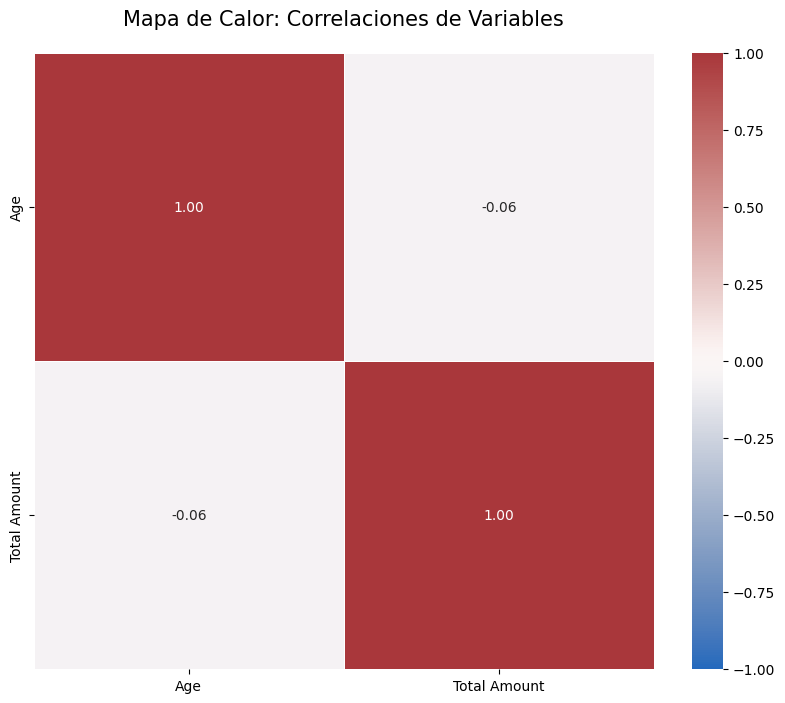


ANÁLISIS DE CORRELACIÓN DE NEGOCIO:

El coeficiente de correlación de Pearson entre la edad del cliente ('Age') y el ingreso 
generado ('Total Amount') es de -0.06.
Este resultado de -0.06 demuestra de forma contundente que existe una relación lineal 
prácticamente nula entre la edad y el monto gastado por transacción.

INSIGHT:

A nivel comercial, esto es un hallazgo sumamente positivo: significa que el ticket de compra 
en la tienda es transversal e independiente del factor demográfico. Un cliente joven de 20 años 
tiene el mismo potencial de generar un ticket alto que un cliente adulto de 60 años. 
Por lo tanto, las estrategias comerciales para aumentar el valor del ticket promedio 
no deben segmentarse por edad, sino que deben enfocarse en incentivos transversales 
como el mix de productos o la experiencia en cajas.



In [6]:
print("--- Generando Mapa de Calor de Correlaciones ---")

# Graficar llamando la función
modulo_p5.analisis_correlacion(datos)

# Extraer valor entre las dos variables
r_valor = datos[['Age', 'Total Amount']].corr().loc['Age', 'Total Amount']

# Interpretación
interpretacion = f"""
ANÁLISIS DE CORRELACIÓN DE NEGOCIO:

El coeficiente de correlación de Pearson entre la edad del cliente ('Age') y el ingreso 
generado ('Total Amount') es de {r_valor:.2f}.
Este resultado de {r_valor:.2f} demuestra de forma contundente que existe una relación lineal 
prácticamente nula entre la edad y el monto gastado por transacción.

INSIGHT:

A nivel comercial, esto es un hallazgo sumamente positivo: significa que el ticket de compra 
en la tienda es transversal e independiente del factor demográfico. Un cliente joven de 20 años 
tiene el mismo potencial de generar un ticket alto que un cliente adulto de 60 años. 
Por lo tanto, las estrategias comerciales para aumentar el valor del ticket promedio 
no deben segmentarse por edad, sino que deben enfocarse en incentivos transversales 
como el mix de productos o la experiencia en cajas.
"""

print(interpretacion)

3.2.2 Comparativa variables clave

### **Nota Metodológica: Curaduría de Variables para el Análisis Comparativo y Temporal**

La configuración de este Dashboard analítico unificado responde a un riguroso criterio de **curaduría de variables**, cuyo objetivo es aislar los componentes estratégicos del negocio y evitar la redundancia de datos. A continuación, se justifica el sustento metodológico detrás de la inclusión y exclusión de las variables del dataset:

#### **1. Dimensiones y Métricas Incluidas (Ejes Estratégicos)**
* **`Gender` y `Product Category` (Variables Categóricas Nominales):** Fueron seleccionadas como las dimensiones maestras de segmentación (*Customer Profiling*). Al ser excluidas de la matriz de correlación lineal debido a restricciones estadísticas del coeficiente de Pearson, este bloque de subplots constituye el espacio metodológico correcto para evaluar su impacto directo sobre el comportamiento del consumidor.
* **`Date` (Dimensión Temporal Continua):** Es la variable fundamental de orden cronológico. Su inclusión es obligatoria para estructurar la serie de tiempo y realizar el *resample* mensual, permitiendo identificar la estacionalidad y evaluar la salud financiera de la empresa a largo plazo.
* **`Total Amount` (Métrica de Valor / KPI Central):** Actúa como nuestra variable dependiente principal en los tres subplots. Se seleccionó para unificar los criterios de éxito comercial, midiendo la masa crítica de ingresos tanto a nivel de segmentos estáticos como en la evolución del flujo de caja.

#### **2. Variables Excluidas (Optimización y Control de Ruido)**
* **`Age` (Variable Demográfica Numérica):** Se excluyó de este módulo debido a que su relación con la facturación ya fue analizada de forma aislada en la fase de correlación lineal.
* **`Quantity` y `Price Per Unit` (Componentes Operativos):** Se descartaron tras un análisis de granularidad (nivel de detalle). Para una visión macro y de alta gerencia, el interés radica en el impacto financiero consolidado (`Total Amount`), por lo que mantener el volumen de artículos o el precio unitario por separado generaría ruido operativo innecesario.
* **`Transaction ID` y `Mes` (Variables de Registro y Control):** El ID de transacción carece de poder predictivo o estratégico al ser un mero correlativo algorítmico. Por su parte, la columna `Mes` se descarta por redundancia analítica, ya que la función procesa directamente la variable nativa de fecha (`Date`) para construir de forma precisa la tendencia temporal.

--- Generando Dashboard Comparativo y Temporal Unificado ---


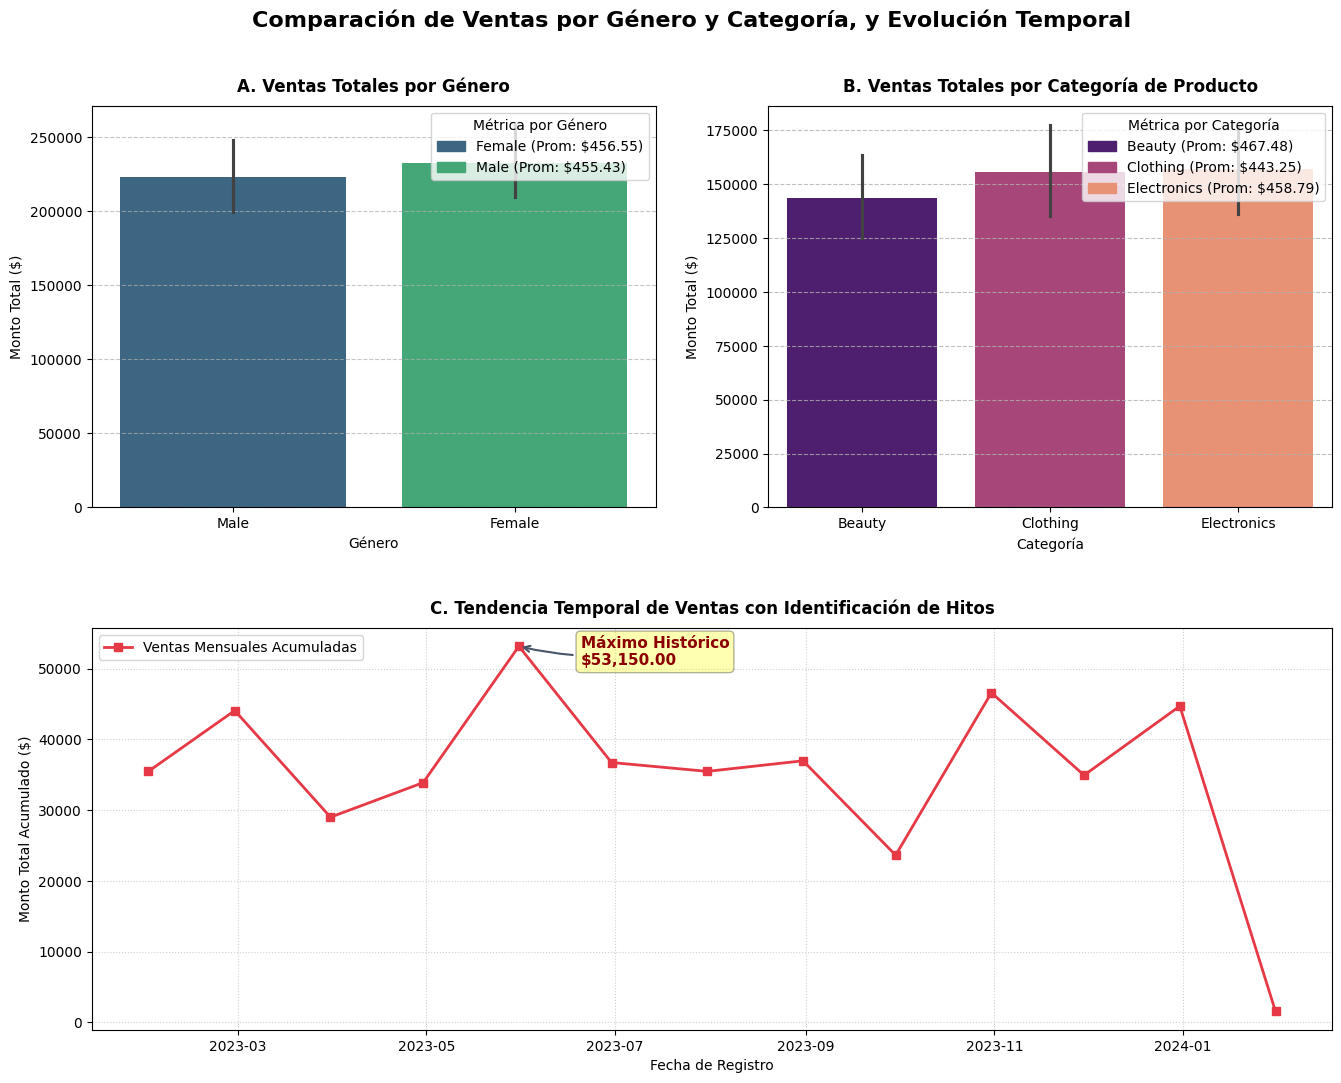


ANÁLISIS ESTRATÉGICO:

• COMPORTAMIENTO CATEGÓRICO nominal: Las ventas acumuladas muestran un liderazgo del segmento 'Mujeres' 
en la dimensión demográfica (aportando $232,840.00), mientras que la unidad de negocio con 
mayor rendimiento comercial es 'Electronics', con una recaudación de $156,905.00.
• COMPORTAMIENTO TEMPORAL: El flujo de caja histórico identificó su hito de operación más alto en el mes de May 2023, 
alcanzando una facturación récord de $53,150.00.



In [7]:
print("--- Generando Dashboard Comparativo y Temporal Unificado ---")
# Graficar llamando a la función
modulo_p5.graficar_analisis_comparativo_y_tendencia(datos)

# Cálculos para interpretación
ventas_genero = datos.groupby('Gender')['Total Amount'].sum()
genero_lider = "Hombres" if ventas_genero.idxmax() == "Male" else "Mujeres"
total_genero_lider = ventas_genero.max()

ventas_cat = datos.groupby('Product Category')['Total Amount'].sum()
cat_lider = ventas_cat.idxmax()
total_cat_lider = ventas_cat.max()

# Preparación analítica de la dimensión temporal
df_temp = datos.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
resumen_temporal = df_temp.resample('ME', on='Date')['Total Amount'].sum()
mes_maximo = resumen_temporal.idxmax().strftime('%B %Y')
monto_maximo = resumen_temporal.max()

# Interpretación
interpretacion_dashboard = f"""
ANÁLISIS ESTRATÉGICO:

• COMPORTAMIENTO CATEGÓRICO nominal: Las ventas acumuladas muestran un liderazgo del segmento '{genero_lider}' 
en la dimensión demográfica (aportando ${total_genero_lider:,.2f}), mientras que la unidad de negocio con 
mayor rendimiento comercial es '{cat_lider}', con una recaudación de ${total_cat_lider:,.2f}.
• COMPORTAMIENTO TEMPORAL: El flujo de caja histórico identificó su hito de operación más alto en el mes de {mes_maximo}, 
alcanzando una facturación récord de ${monto_maximo:,.2f}.
"""

print(interpretacion_dashboard)